In [56]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

In [ ]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
base_dir = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/BSS/ensemble"
lead_time = "4"
hours = [f"{h:02d}" for h in range(0, 24, 6)]
group_size = 6
map_shape = (350, 370)

DISPLAY_LON_MIN = 21.167515 + 1
DISPLAY_LON_MAX = 35.316326 - 2
DISPLAY_LAT_MIN = -18.414806 + 0.5
DISPLAY_LAT_MAX = -7.9918404

# ---------------------------------------------------------------------
# Load geolocation grid
# ---------------------------------------------------------------------
y_min, y_max = 580, 930
x_min, x_max = 1480, 1850
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")
Zambia_lons = geodata["lon"][y_min:y_max, x_min:x_max]
Zambia_lats = geodata["lat"][y_min:y_max, x_min:x_max]

# ---------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------
def hour_range(h):
    start = int(h)
    return [f"{x:02d}" for x in range(start, start + group_size)]

def load_map(path):
    arr = np.load(path)
    if arr.ndim == 1:
        arr = arr.reshape(map_shape)
    return arr

# ---------------------------------------------------------------------
# Aggregate by 6-hour window
# ---------------------------------------------------------------------
groups = []
for h in hours:
    matched_hours = hour_range(h)
    z_maps, c_maps = [], []
    for mh in matched_hours:
        z_file = os.path.join(base_dir, f"bss_zcast_hour_{mh}_t{lead_time}.npy")
        c_file = os.path.join(base_dir, f"bss_netncc_hour_{mh}_t{lead_time}.npy")
        if os.path.exists(z_file) and os.path.exists(c_file):
            z_maps.append(load_map(z_file))
            c_maps.append(load_map(c_file))
    if len(z_maps) > 0:
        mean_z = np.nanmean(np.stack(z_maps), axis=0)
        mean_c = np.nanmean(np.stack(c_maps), axis=0)
        groups.append((h, mean_c, mean_z))
        print(f"Averaged {len(z_maps)} files for {h}–{int(h)+5:02d} UTC")
    else:
        print(f"No data for {h}–{int(h)+5:02d} UTC")

Averaged 6 files for 00–05 UTC
Averaged 6 files for 06–11 UTC
Averaged 6 files for 12–17 UTC
Averaged 6 files for 18–23 UTC


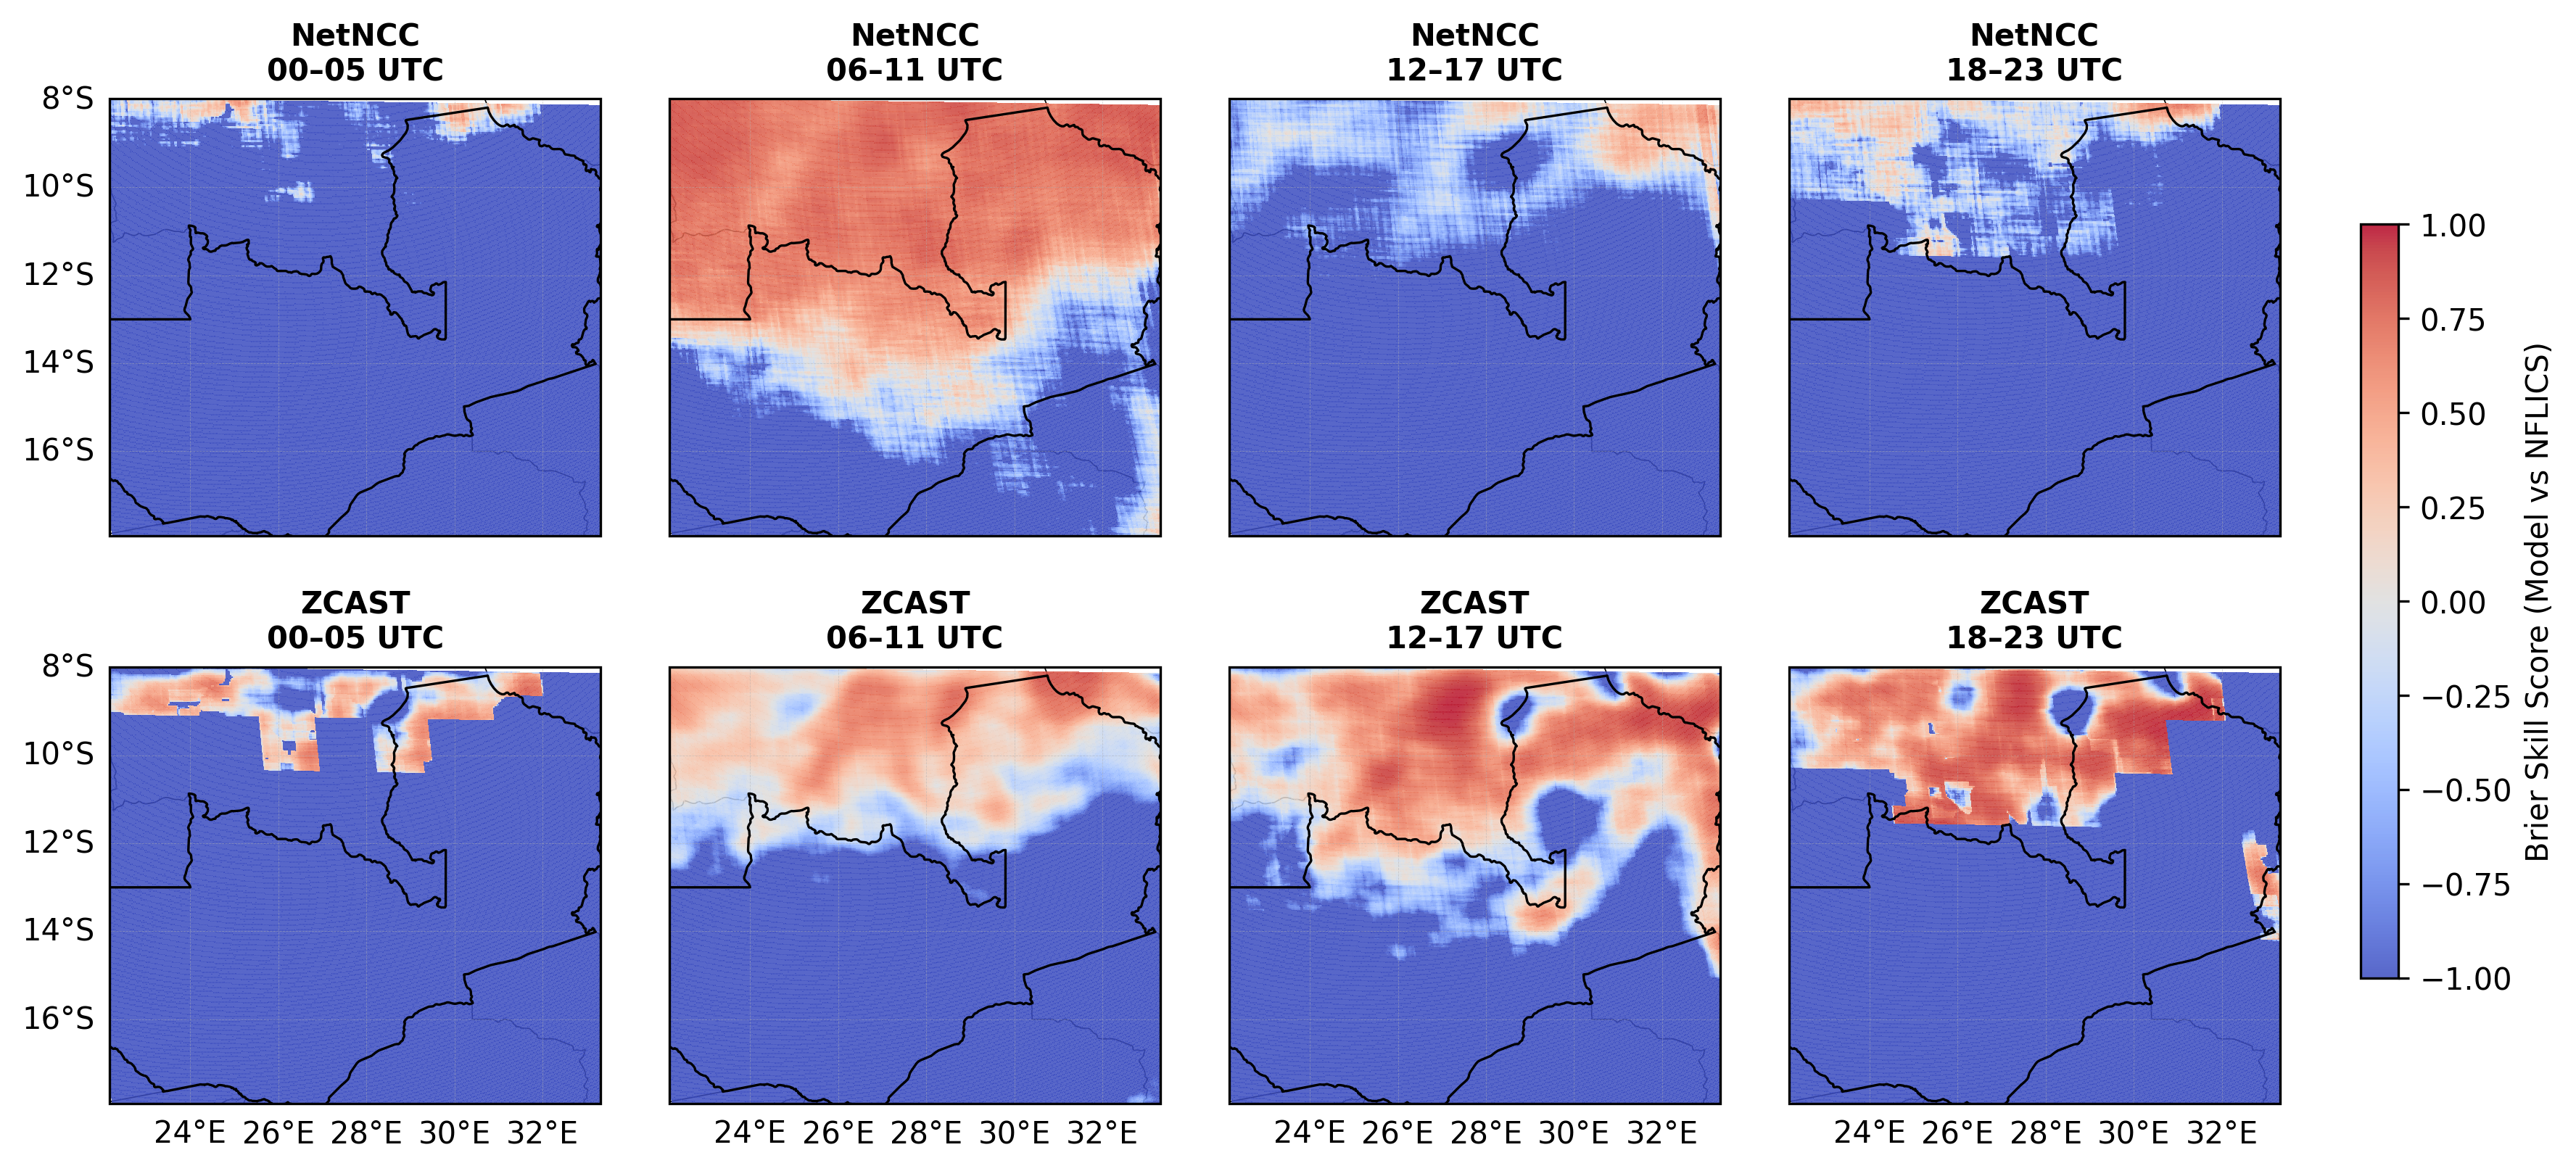

In [58]:
if not groups:
    raise RuntimeError("No valid data found for plotting.")

n_groups = len(groups)
fig, axes = plt.subplots(
    2, n_groups,
    figsize=(4 * n_groups, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)
plt.subplots_adjust(hspace=0.3, wspace=0.05)

vmin, vmax = -1, 1
import matplotlib.ticker as mticker  # for tick locators

# Load Zambia outline once
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m',
                                        category='cultural', name=shapename)
zambia_geom = None
for country in shpreader.Reader(countries_shp).records():
    if country.attributes['NAME'] == 'Zambia':
        zambia_geom = country.geometry
        break

# Prepare 2-degree tick locators aligned to even degrees
lon_start = np.floor(DISPLAY_LON_MIN / 2) * 2
lon_end   = np.ceil(DISPLAY_LON_MAX / 2) * 2
lat_start = np.floor(DISPLAY_LAT_MIN / 2) * 2
lat_end   = np.ceil(DISPLAY_LAT_MAX / 2) * 2
x_ticks = np.arange(lon_start, lon_end + 2, 2)
y_ticks = np.arange(lat_start, lat_end + 2, 2)

for i, (h, netncc_map, zcast_map) in enumerate(groups):
    for row, (data, title_prefix) in enumerate([(netncc_map, "NetNCC"), (zcast_map, "ZCAST")]):
        ax = axes[row, i]
        ax.set_extent([DISPLAY_LON_MIN, DISPLAY_LON_MAX,
                       DISPLAY_LAT_MIN, DISPLAY_LAT_MAX], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=1)
        ax.add_feature(cfeature.RIVERS, linewidth=0.2, alpha=0.3, zorder=1)

        im = ax.pcolormesh(
            Zambia_lons, Zambia_lats, data,
            transform=ccrs.PlateCarree(),
            cmap="coolwarm", vmin=vmin, vmax=vmax,
            shading="auto", zorder=2, alpha=0.85
        )

        if zambia_geom is not None:
            ax.add_geometries([zambia_geom], ccrs.PlateCarree(),
                              facecolor='none', edgecolor='black',
                              linewidth=0.8, zorder=4)

        ax.set_title(f"{title_prefix}\n{h}–{int(h)+5:02d} UTC",
                     fontsize=10, fontweight="bold")

        # Gridlines and labels (every 2 degrees)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2,
                          linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = (row == 1)   # only bottom row shows longitude labels
        gl.left_labels = (i == 0)       # only leftmost column shows latitude labels
        gl.xlocator = mticker.FixedLocator(x_ticks)
        gl.ylocator = mticker.FixedLocator(y_ticks)

# Shared colourbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, pad=0.03,
                    label="Brier Skill Score (Model vs NFLICS)")

plt.show()


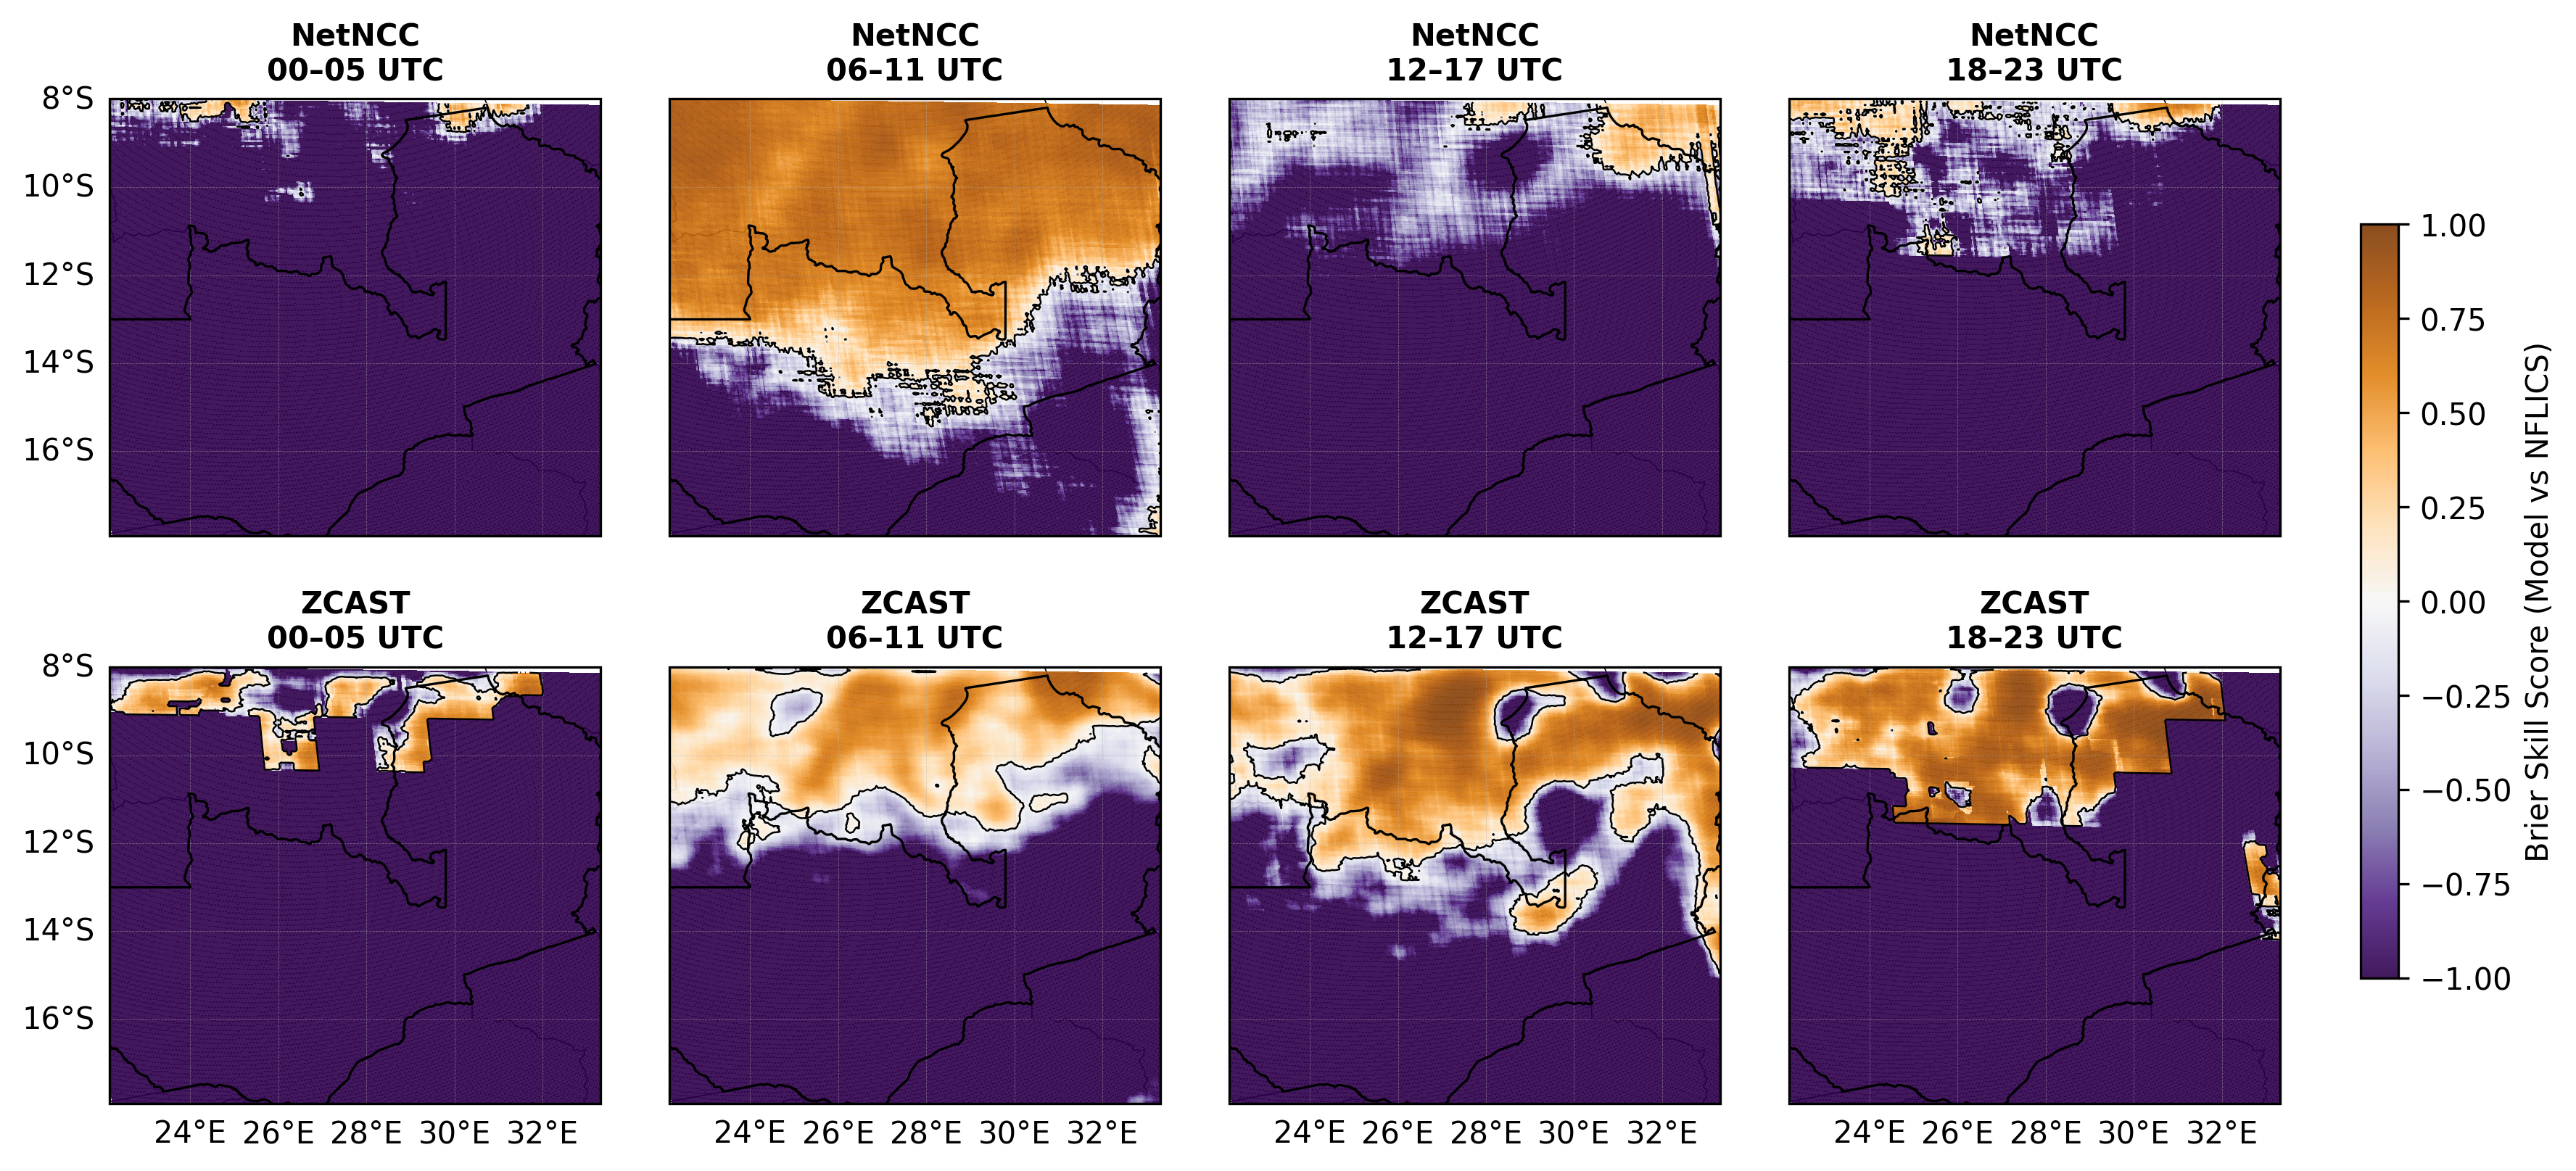

In [60]:
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

if not groups:
    raise RuntimeError("No valid data found for plotting.")

n_groups = len(groups)
fig, axes = plt.subplots(
    2, n_groups,
    figsize=(4 * n_groups, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)
plt.subplots_adjust(hspace=0.3, wspace=0.05)

# Diverging colormap with white at zero
vmin, vmax = -1, 1
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.get_cmap("PuOr_r")  # better contrast between positive/negative

# Load Zambia outline once
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m',
                                        category='cultural', name=shapename)
zambia_geom = None
for country in shpreader.Reader(countries_shp).records():
    if country.attributes['NAME'] == 'Zambia':
        zambia_geom = country.geometry
        break

# Prepare 2° tick locators
lon_start = np.floor(DISPLAY_LON_MIN / 2) * 2
lon_end   = np.ceil(DISPLAY_LON_MAX / 2) * 2
lat_start = np.floor(DISPLAY_LAT_MIN / 2) * 2
lat_end   = np.ceil(DISPLAY_LAT_MAX / 2) * 2
x_ticks = np.arange(lon_start, lon_end + 2, 2)
y_ticks = np.arange(lat_start, lat_end + 2, 2)

for i, (h, netncc_map, zcast_map) in enumerate(groups):
    for row, (data, title_prefix) in enumerate([(netncc_map, "NetNCC"), (zcast_map, "ZCAST")]):
        ax = axes[row, i]
        ax.set_extent([DISPLAY_LON_MIN, DISPLAY_LON_MAX,
                       DISPLAY_LAT_MIN, DISPLAY_LAT_MAX], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=1)
        ax.add_feature(cfeature.RIVERS, linewidth=0.2, alpha=0.3, zorder=1)

        im = ax.pcolormesh(
            Zambia_lons, Zambia_lats, data,
            transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm,
            shading="auto", zorder=2, alpha=0.9
        )

        # Add contour for zero-skill boundary
        ax.contour(
            Zambia_lons, Zambia_lats, data,
            levels=[0], colors="black", linewidths=0.6,
            transform=ccrs.PlateCarree(), zorder=5
        )

        if zambia_geom is not None:
            ax.add_geometries([zambia_geom], ccrs.PlateCarree(),
                              facecolor='none', edgecolor='black',
                              linewidth=0.8, zorder=6)

        ax.set_title(f"{title_prefix}\n{h}–{int(h)+5:02d} UTC",
                     fontsize=10, fontweight="bold")

        # Gridlines every 2 degrees
        gl = ax.gridlines(draw_labels=True, linewidth=0.2,
                          linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = (row == 1)
        gl.left_labels = (i == 0)
        gl.xlocator = mticker.FixedLocator(x_ticks)
        gl.ylocator = mticker.FixedLocator(y_ticks)

# Shared colourbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, pad=0.03,
                    label="Brier Skill Score (Model vs NFLICS)")

plt.show()
